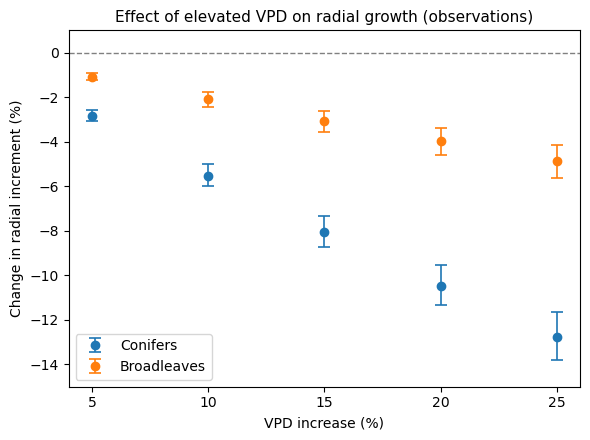

In [1]:
import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt

fd_nonlin = '/glade/derecho/scratch/brendanc/VPD/growth_model/nonlin'
fd_new    = '/glade/derecho/scratch/brendanc/VPD/growth_model/nonlin/max_min_vpd_glm_justvpd'

VPD_LEVELS = [5, 10, 15, 20, 25]

SPECIES = {
    'abies':       ('abies_alba',          'conifer'),
    'picea':       ('picea_abies',         'conifer'),
    'pinus':       ('pinus_sylvestris',    'conifer'),
    'fagus':       ('fagus_sylvatica',     'broadleaf'),
    'fraxinus':    ('fraxinus_excelsior',  'broadleaf'),
    'quercus_pet': ('quercus_petraea',     'broadleaf'),
    'quercus_pub': ('quercus_pubescens',   'broadleaf'),
}

def load_da(fd, filename):
    ds = xr.open_dataset(os.path.join(fd, filename))
    var = [v for v in ds.data_vars][0]
    return ds[var]

def weighted_mean_1989_1993(da, w):
    return da.weighted(w).mean(("lat", "lon"), skipna=True).sel(time=slice(1989, 1993)).mean()

_ref = load_da(fd_nonlin, 'pinus_sylvestris_HIST_Europe_annual_radial_growth_1978-2014_nonlin.nc')
w = np.cos(np.deg2rad(_ref.lat))

results = {}

for key, (sp, stype) in SPECIES.items():
    # Each scenario compared to its own HIST baseline
    base_glmns = load_da(fd_new, f'{sp}_HIST_1978-2014_glmns.nc')
    base_max   = load_da(fd_new, f'{sp}_HIST_1978-2014_vpd_maxgrowth.nc')
    base_min   = load_da(fd_new, f'{sp}_HIST_1978-2014_vpd_mingrowth.nc')

    mean_base_glmns = weighted_mean_1989_1993(base_glmns, w)
    mean_base_max   = weighted_mean_1989_1993(base_max,   w)
    mean_base_min   = weighted_mean_1989_1993(base_min,   w)

    pct_glmns = []
    pct_max   = []
    pct_min   = []

    for pct in VPD_LEVELS:
        da_glmns = load_da(fd_new, f'{sp}_HIST_1978-2014_glmns_plus{pct}pct.nc')
        da_max   = load_da(fd_new, f'{sp}_HIST_1978-2014_maxvpd_plus{pct}pct.nc')
        da_min   = load_da(fd_new, f'{sp}_HIST_1978-2014_minvpd_plus{pct}pct.nc')

        m_glmns = weighted_mean_1989_1993(da_glmns, w)
        m_max   = weighted_mean_1989_1993(da_max,   w)
        m_min   = weighted_mean_1989_1993(da_min,   w)

        # Each compared to its own HIST baseline
        pct_glmns.append(float((m_glmns - mean_base_glmns) / mean_base_glmns * 100))
        pct_max.append(  float((m_max   - mean_base_max)   / mean_base_max   * 100))
        pct_min.append(  float((m_min   - mean_base_min)   / mean_base_min   * 100))

    results[key] = {
        'type':      stype,
        'pct_glmns': np.array(pct_glmns),
        'pct_max':   np.array(pct_max),
        'pct_min':   np.array(pct_min),
    }

def group_mean(field, group):
    arrays = [results[k][field] for k in results if results[k]['type'] == group]
    return np.mean(arrays, axis=0)

vpd_levels = np.array(VPD_LEVELS)

fig, ax = plt.subplots(figsize=(6, 4.5))

for group, color, label in [('conifer', 'tab:blue', 'Conifers'), ('broadleaf', 'tab:orange', 'Broadleaves')]:
    mean_vals = group_mean('pct_glmns', group)
    max_vals  = group_mean('pct_max',   group)
    min_vals  = group_mean('pct_min',   group)

    err_up = np.abs(max_vals - mean_vals)
    err_dn = np.abs(mean_vals - min_vals)

    ax.errorbar(vpd_levels, mean_vals,
                yerr=[err_dn, err_up],
                fmt='o', color=color, label=label,
                capsize=4, capthick=1.2, elinewidth=1.2,
                linestyle='none')

ax.set_xlabel("VPD increase (%)")
ax.set_ylabel("Change in radial increment (%)")
ax.set_xticks([5, 10, 15, 20, 25])
ax.set_title("Effect of elevated VPD on radial growth (observations)", fontsize=11)
ax.legend(loc="lower left")
ax.axhline(0, color="grey", linewidth=1, linestyle="--")
plt.ylim(-15, 1)
plt.tight_layout()
savedir = "/glade/derecho/scratch/brendanc/make_pft/plus_vpd"
# plt.savefig(f"{savedir}/VPD_increase_observations.png", dpi=300, bbox_inches="tight")
plt.show()

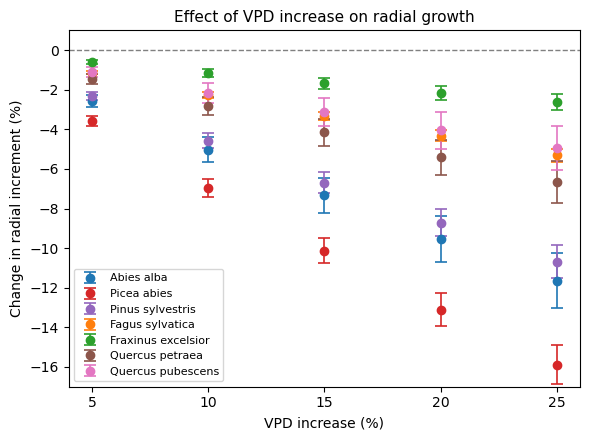

In [2]:
import matplotlib.pyplot as plt

SPECIES_PLOT = {
    'abies':       ('Abies alba',          'tab:blue'),
    'picea':       ('Picea abies',         'tab:red'),
    'pinus':       ('Pinus sylvestris',    'tab:purple'),
    'fagus':       ('Fagus sylvatica',     'tab:orange'),
    'fraxinus':    ('Fraxinus excelsior',  'tab:green'),
    'quercus_pet': ('Quercus petraea',     'tab:brown'),
    'quercus_pub': ('Quercus pubescens',   'tab:pink'),
}

vpd_levels = np.array(VPD_LEVELS)

fig, ax = plt.subplots(figsize=(6, 4.5))

for key, (label, color) in SPECIES_PLOT.items():
    vals   = results[key]['pct_glmns']
    err_up = np.abs(results[key]['pct_max'] - vals)
    err_dn = np.abs(vals - results[key]['pct_min'])

    ax.errorbar(vpd_levels, vals,
                yerr=[err_dn, err_up],
                fmt='o', color=color, label=label,
                capsize=4, capthick=1.2, elinewidth=1.2,
                linestyle='none')

ax.set_xlabel("VPD increase (%)")
ax.set_ylabel("Change in radial increment (%)")
ax.set_xticks([5, 10, 15, 20, 25])
ax.set_title("Effect of VPD increase on radial growth", fontsize=11)
ax.axhline(0, color="grey", linewidth=1, linestyle="--")
ax.legend(loc="lower left", fontsize=8)
plt.ylim(-17, 1)
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd

rows = []
for key, (sp, stype) in SPECIES.items():
    for i, pct in enumerate(VPD_LEVELS):
        rows.append({
            'species': key,
            'vpd_pct': pct,
            'glmns':   round(float(results[key]['pct_glmns'][i]), 3),
            'max':     round(float(results[key]['pct_max'][i]),   3),
            'min':     round(float(results[key]['pct_min'][i]),   3),
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

    species  vpd_pct   glmns     max     min
      abies        5  -2.575  -2.253  -2.896
      abies       10  -5.019  -4.398  -5.636
      abies       15  -7.341  -6.442  -8.230
      abies       20  -9.549  -8.392 -10.688
      abies       25 -11.651 -10.254 -13.021
      picea        5  -3.598  -3.351  -3.837
      picea       10  -6.969  -6.500  -7.420
      picea       15 -10.132  -9.464 -10.771
      picea       20 -13.104 -12.258 -13.911
      picea       25 -15.901 -14.894 -16.858
      pinus        5  -2.337  -2.131  -2.529
      pinus       10  -4.567  -4.172  -4.934
      pinus       15  -6.698  -6.130  -7.224
      pinus       20  -8.737  -8.011  -9.408
      pinus       25 -10.690  -9.819 -11.493
      fagus        5  -1.153  -1.078  -1.229
      fagus       10  -2.256  -2.110  -2.405
      fagus       15  -3.314  -3.101  -3.530
      fagus       20  -4.329  -4.053  -4.609
      fagus       25  -5.306  -4.970  -5.645
   fraxinus        5  -0.599  -0.504  -0.698
   fraxinu

In [4]:
import numpy as np
import xarray as xr

path_base = "/glade/derecho/scratch/brendanc/fates_output/plus_vpd/"

ds_ddbh   = xr.open_dataset(path_base + "fates_hist_ctsm5.3.085_1989-1993.clm2.h1a.FATES_DDBH_latlon.nc")
ds_nplant = xr.open_dataset(path_base + "fates_hist_ctsm5.3.085_1989-1993.clm2.h1a.FATES_NPLANT_latlon.nc")

ddb = ds_ddbh["FATES_DDBH_latlon"]       
npl = ds_nplant["FATES_NPLANT_latlon"]   

ddb = ddb.sel(time=ddb['time'].dt.month.isin([4,5,6,7,8,9]))
npl = npl.sel(time=npl['time'].dt.month.isin([4,5,6,7,8,9]))

ddb = ddb.sum(dim="fates_levscls")
npl = npl.sum(dim="fates_levscls")


npl = npl.where(npl > 0)

divide = (ddb / npl)
diameter_mm_yr = divide * 1000
radial_mm_yr = diameter_mm_yr * 0.5

rad = radial_mm_yr

rad = rad.assign_coords(lon=(((rad.lon + 180) % 360) - 180)).sortby('lon')
euro_hist = rad.sel(lat=slice(35, 72), lon=slice(-11, 40))

In [5]:
path_base = "/glade/derecho/scratch/brendanc/fates_output/plus_vpd/"

ds_ddbh   = xr.open_dataset(path_base + "fates_ctsm5.3.085_vpdmod_plus5pct_1989-1993_BB.clm2.h1a.FATES_DDBH_latlon.nc")
ds_nplant = xr.open_dataset(path_base + "fates_ctsm5.3.085_vpdmod_plus5pct_1989-1993_BB.clm2.h1a.FATES_NPLANT_latlon.nc")

ddb = ds_ddbh["FATES_DDBH_latlon"]       
npl = ds_nplant["FATES_NPLANT_latlon"]   

ddb = ddb.sel(time=ddb['time'].dt.month.isin([4,5,6,7,8,9]))
npl = npl.sel(time=npl['time'].dt.month.isin([4,5,6,7,8,9]))

ddb = ddb.sum(dim="fates_levscls")
npl = npl.sum(dim="fates_levscls")

npl = npl.where(npl > 0)

divide = (ddb / npl)
diameter_mm_yr = divide * 1000
radial_mm_yr = diameter_mm_yr * 0.5

rad = radial_mm_yr
rad = rad.assign_coords(lon=(((rad.lon + 180) % 360) - 180)).sortby('lon')
euro_plus5 = rad.sel(lat=slice(35, 72), lon=slice(-11, 40))

In [6]:
path_base = "/glade/derecho/scratch/brendanc/fates_output/plus_vpd/"

ds_ddbh   = xr.open_dataset(path_base + "fates_ctsm5.3.085_vpdmod_plus10pct_1989-1993_BB.clm2.h1a.FATES_DDBH_latlon.nc")
ds_nplant = xr.open_dataset(path_base + "fates_ctsm5.3.085_vpdmod_plus10pct_1989-1993_BB.clm2.h1a.FATES_NPLANT_latlon.nc")

ddb = ds_ddbh["FATES_DDBH_latlon"]       
npl = ds_nplant["FATES_NPLANT_latlon"]   

ddb = ddb.sel(time=ddb['time'].dt.month.isin([4,5,6,7,8,9]))
npl = npl.sel(time=npl['time'].dt.month.isin([4,5,6,7,8,9]))

ddb = ddb.sum(dim="fates_levscls")
npl = npl.sum(dim="fates_levscls")

npl = npl.where(npl > 0)

divide = (ddb / npl)
diameter_mm_yr = divide * 1000
radial_mm_yr = diameter_mm_yr * 0.5

rad = radial_mm_yr

rad = rad.assign_coords(lon=(((rad.lon + 180) % 360) - 180)).sortby('lon')
euro_plus10 = rad.sel(lat=slice(35, 72), lon=slice(-11, 40))

In [7]:
path_base = "/glade/derecho/scratch/brendanc/fates_output/plus_vpd/"

ds_ddbh   = xr.open_dataset(path_base + "fates_ctsm5.3.085_vpdmod_plus15pct_1989-1993_BB.clm2.h1a.FATES_DDBH_latlon.nc")
ds_nplant = xr.open_dataset(path_base + "fates_ctsm5.3.085_vpdmod_plus15pct_1989-1993_BB.clm2.h1a.FATES_NPLANT_latlon.nc")

ddb = ds_ddbh["FATES_DDBH_latlon"]       
npl = ds_nplant["FATES_NPLANT_latlon"]   

ddb = ddb.sel(time=ddb['time'].dt.month.isin([4,5,6,7,8,9]))
npl = npl.sel(time=npl['time'].dt.month.isin([4,5,6,7,8,9]))

ddb = ddb.sum(dim="fates_levscls")
npl = npl.sum(dim="fates_levscls")

npl = npl.where(npl > 0)

divide = (ddb / npl)
diameter_mm_yr = divide * 1000
radial_mm_yr = diameter_mm_yr * 0.5

rad = radial_mm_yr

rad = rad.assign_coords(lon=(((rad.lon + 180) % 360) - 180)).sortby('lon')
euro_plus15 = rad.sel(lat=slice(35, 72), lon=slice(-11, 40))

In [8]:
path_base = "/glade/derecho/scratch/brendanc/fates_output/plus_vpd/"

ds_ddbh   = xr.open_dataset(path_base + "fates_ctsm5.3.085_vpdmod_plus20pct_1989-1993_BB.clm2.h1a.FATES_DDBH_latlon.nc")
ds_nplant = xr.open_dataset(path_base + "fates_ctsm5.3.085_vpdmod_plus20pct_1989-1993_BB.clm2.h1a.FATES_NPLANT_latlon.nc")

ddb = ds_ddbh["FATES_DDBH_latlon"]       
npl = ds_nplant["FATES_NPLANT_latlon"]   

ddb = ddb.sel(time=ddb['time'].dt.month.isin([4,5,6,7,8,9]))
npl = npl.sel(time=npl['time'].dt.month.isin([4,5,6,7,8,9]))

ddb = ddb.sum(dim="fates_levscls")
npl = npl.sum(dim="fates_levscls")

npl = npl.where(npl > 0)

divide = (ddb / npl)
diameter_mm_yr = divide * 1000
radial_mm_yr = diameter_mm_yr * 0.5

rad = radial_mm_yr

rad = rad.assign_coords(lon=(((rad.lon + 180) % 360) - 180)).sortby('lon')
euro_plus20 = rad.sel(lat=slice(35, 72), lon=slice(-11, 40))

In [9]:
path_base = "/glade/derecho/scratch/brendanc/fates_output/plus_vpd/"

ds_ddbh   = xr.open_dataset(path_base + "fates_ctsm5.3.085_vpdmod_plus25pct_1989-1993_BB.clm2.h1a.FATES_DDBH_latlon.nc")
ds_nplant = xr.open_dataset(path_base + "fates_ctsm5.3.085_vpdmod_plus25pct_1989-1993_BB.clm2.h1a.FATES_NPLANT_latlon.nc")

ddb = ds_ddbh["FATES_DDBH_latlon"]       
npl = ds_nplant["FATES_NPLANT_latlon"]   

ddb = ddb.sel(time=ddb['time'].dt.month.isin([4,5,6,7,8,9]))
npl = npl.sel(time=npl['time'].dt.month.isin([4,5,6,7,8,9]))

ddb = ddb.sum(dim="fates_levscls")
npl = npl.sum(dim="fates_levscls")

npl = npl.where(npl > 0)

divide = (ddb / npl)
diameter_mm_yr = divide * 1000
radial_mm_yr = diameter_mm_yr * 0.5

rad = radial_mm_yr

rad = rad.assign_coords(lon=(((rad.lon + 180) % 360) - 180)).sortby('lon')
euro_plus25 = rad.sel(lat=slice(35, 72), lon=slice(-11, 40))

In [10]:
import matplotlib.pyplot as plt
import numpy as np

pfts_conifer = [1, 3]
pfts_broadleaf = [5, 6]

def area_weighted_diff(hist, plus, pfts):
    hist_p = hist.sel(fates_levpft=pfts).mean("time").mean("fates_levpft")
    plus_p = plus.sel(fates_levpft=pfts).mean("time").mean("fates_levpft")

    dif = (plus_p - hist_p) / hist_p
    dif = dif * 100
    dif = dif.where((dif <= 20) & (dif >= -20))

    weights = np.cos(np.deg2rad(dif["lat"]))
    weights_2d = weights.broadcast_like(dif)

    return (dif * weights_2d).sum(dim=("lat", "lon")) / weights_2d.where(~np.isnan(dif)).sum(dim=("lat", "lon"))

dif_conifer_plus5  = area_weighted_diff(euro_hist, euro_plus5,  pfts_conifer)
dif_conifer_plus10 = area_weighted_diff(euro_hist, euro_plus10, pfts_conifer)
dif_conifer_plus15 = area_weighted_diff(euro_hist, euro_plus15, pfts_conifer)
dif_conifer_plus20 = area_weighted_diff(euro_hist, euro_plus20, pfts_conifer)
dif_conifer_plus25 = area_weighted_diff(euro_hist, euro_plus25, pfts_conifer)

dif_broadleaf_plus5  = area_weighted_diff(euro_hist, euro_plus5,  pfts_broadleaf)
dif_broadleaf_plus10 = area_weighted_diff(euro_hist, euro_plus10, pfts_broadleaf)
dif_broadleaf_plus15 = area_weighted_diff(euro_hist, euro_plus15, pfts_broadleaf)
dif_broadleaf_plus20 = area_weighted_diff(euro_hist, euro_plus20, pfts_broadleaf)
dif_broadleaf_plus25 = area_weighted_diff(euro_hist, euro_plus25, pfts_broadleaf)

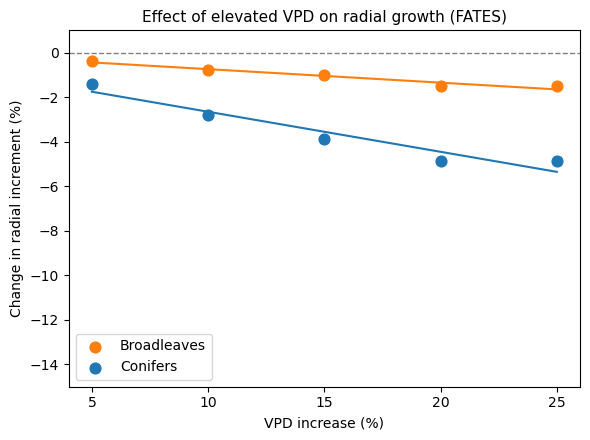

In [11]:
import matplotlib.pyplot as plt
import numpy as np

vpd_levels = np.array([5, 10, 15, 20, 25])

conifer_vals = np.array([
    float(dif_conifer_plus5.values),
    float(dif_conifer_plus10.values),
    float(dif_conifer_plus15.values),
    float(dif_conifer_plus20.values),
    float(dif_conifer_plus25.values)
])

broadleaf_vals = np.array([
    float(dif_broadleaf_plus5.values),
    float(dif_broadleaf_plus10.values),
    float(dif_broadleaf_plus15.values),
    float(dif_broadleaf_plus20.values),
    float(dif_broadleaf_plus25.values)
])


plt.figure(figsize=(6,4.5))

plt.scatter(vpd_levels, broadleaf_vals, color="tab:orange", s=60, label="Broadleaves")
m_broad, b_broad = np.polyfit(vpd_levels, broadleaf_vals, 1)
plt.plot(vpd_levels, m_broad*vpd_levels + b_broad, color="tab:orange")

plt.scatter(vpd_levels, conifer_vals, color="tab:blue", s=60, label="Conifers")
m_conifer, b_conifer = np.polyfit(vpd_levels, conifer_vals, 1)
plt.plot(vpd_levels, m_conifer*vpd_levels + b_conifer, color="tab:blue")

plt.axhline(0, color="grey", linewidth=1, linestyle="--")

plt.xlabel("VPD increase (%)")
plt.ylabel("Change in radial increment (%)")
plt.title("Effect of elevated VPD on radial growth (FATES)",fontsize=11)
plt.xticks([5, 10, 15, 20, 25])
plt.ylim(-15, 1)
plt.legend(loc="lower left")
plt.tight_layout()
savedir = "/glade/derecho/scratch/brendanc/make_pft/plus_vpd"
#plt.savefig(f"{savedir}/VPD_increase_fates.png", dpi=300, bbox_inches="tight")
#plt.show()

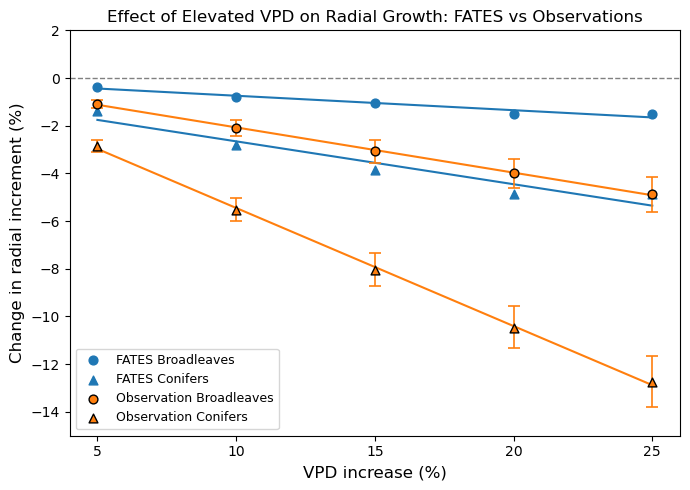

In [12]:
import matplotlib.pyplot as plt
import numpy as np

vpd_levels = np.array(VPD_LEVELS)

# FATES values
fates_conifer_vals = np.array([
    float(dif_conifer_plus5.values),
    float(dif_conifer_plus10.values),
    float(dif_conifer_plus15.values),
    float(dif_conifer_plus20.values),
    float(dif_conifer_plus25.values)
])
fates_broad_vals = np.array([
    float(dif_broadleaf_plus5.values),
    float(dif_broadleaf_plus10.values),
    float(dif_broadleaf_plus15.values),
    float(dif_broadleaf_plus20.values),
    float(dif_broadleaf_plus25.values)
])

# Obs mean values
obs_broad_vals   = group_mean('pct_glmns', 'broadleaf')
obs_conifer_vals = group_mean('pct_glmns', 'conifer')

# Obs error bars
obs_broad_max   = group_mean('pct_max', 'broadleaf')
obs_broad_min   = group_mean('pct_min', 'broadleaf')
obs_conifer_max = group_mean('pct_max', 'conifer')
obs_conifer_min = group_mean('pct_min', 'conifer')

obs_broad_err_up   = np.abs(obs_broad_max   - obs_broad_vals)
obs_broad_err_dn   = np.abs(obs_broad_vals  - obs_broad_min)
obs_conifer_err_up = np.abs(obs_conifer_max - obs_conifer_vals)
obs_conifer_err_dn = np.abs(obs_conifer_vals - obs_conifer_min)

color_fates  = "tab:blue"
color_obs    = "tab:orange"
marker_broad = "o"
marker_conif = "^"

fig, ax = plt.subplots(figsize=(7, 5))

# --- FATES lines (zorder=1) then markers (zorder=3)
m_fb, b_fb = np.polyfit(vpd_levels, fates_broad_vals, 1)
ax.plot(vpd_levels, m_fb*vpd_levels + b_fb, color=color_fates, zorder=1)
ax.scatter(vpd_levels, fates_broad_vals, marker=marker_broad, color=color_fates,
           s=40, label="FATES Broadleaves", zorder=3)

m_fc, b_fc = np.polyfit(vpd_levels, fates_conifer_vals, 1)
ax.plot(vpd_levels, m_fc*vpd_levels + b_fc, color=color_fates, zorder=1)
ax.scatter(vpd_levels, fates_conifer_vals, marker=marker_conif, color=color_fates,
           s=40, label="FATES Conifers", zorder=3)

# --- Obs lines (zorder=1), error bars (zorder=2), markers (zorder=3)
m_ob, b_ob = np.polyfit(vpd_levels, obs_broad_vals, 1)
ax.plot(vpd_levels, m_ob*vpd_levels + b_ob, color=color_obs, zorder=1)
ax.errorbar(vpd_levels, obs_broad_vals,
            yerr=[obs_broad_err_dn, obs_broad_err_up],
            fmt='none', color=color_obs, ecolor=color_obs,
            elinewidth=1.2, capsize=4, capthick=1.2, zorder=2)
ax.scatter(vpd_levels, obs_broad_vals,
           marker=marker_broad, color=color_obs, edgecolor='black',
           s=40, label="Observation Broadleaves", zorder=3)

m_oc, b_oc = np.polyfit(vpd_levels, obs_conifer_vals, 1)
ax.plot(vpd_levels, m_oc*vpd_levels + b_oc, color=color_obs, zorder=1)
ax.errorbar(vpd_levels, obs_conifer_vals,
            yerr=[obs_conifer_err_dn, obs_conifer_err_up],
            fmt='none', color=color_obs, ecolor=color_obs,
            elinewidth=1.2, capsize=4, capthick=1.2, zorder=2)
ax.scatter(vpd_levels, obs_conifer_vals,
           marker=marker_conif, color=color_obs, edgecolor='black',
           s=40, label="Observation Conifers", zorder=3)

ax.axhline(0, color="grey", linewidth=1, linestyle="--", zorder=1)
ax.set_xlabel("VPD increase (%)", fontsize=12)
ax.set_ylabel("Change in radial increment (%)", fontsize=12)
ax.set_title("Effect of Elevated VPD on Radial Growth: FATES vs Observations", fontsize=12)
ax.set_xticks([5, 10, 15, 20, 25])
ax.set_ylim(-15, 2)
ax.legend(loc="lower left", fontsize=9)

plt.tight_layout()
savedir = "/glade/derecho/scratch/brendanc/fates_output/constco2/GRL_figures/new"
plt.savefig(f"{savedir}/GRL_Fig3_new.pdf", dpi=600, bbox_inches="tight")
#plt.show()